In [24]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve, confusion_matrix,accuracy_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df=pd.read_csv('diabetes_dataset.csv')
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [28]:
df.describe

<bound method NDFrame.describe of        year  gender   age location  race:AfricanAmerican  race:Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0                   

In [30]:
df.columns

Index(['year', 'gender', 'age', 'location', 'race:AfricanAmerican',
       'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other',
       'hypertension', 'heart_disease', 'smoking_history', 'bmi',
       'hbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [32]:
## we drop the unnessessary information
df.drop(columns=['year','location','race:AfricanAmerican','race:Asian','race:Caucasian','race:Hispanic','race:Other','smoking_history'],inplace=True)
df

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
0,Female,32.0,0,0,27.32,5.0,100,0
1,Female,29.0,0,0,19.95,5.0,90,0
2,Male,18.0,0,0,23.76,4.8,160,0
3,Male,41.0,0,0,27.32,4.0,159,0
4,Female,52.0,0,0,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...
99995,Female,33.0,0,0,21.21,6.5,90,0
99996,Female,80.0,0,0,36.66,5.7,100,0
99997,Male,46.0,0,0,36.12,6.2,158,0
99998,Female,51.0,0,0,29.29,6.0,155,0


In [34]:
encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])

label_mapping = dict(zip(encoder.classes_, range(len(encoder.classes_))))

print("Label Encoding Mapping:", label_mapping)

Label Encoding Mapping: {'Female': 0, 'Male': 1, 'Other': 2}


In [36]:
df.tail()

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
99995,0,33.0,0,0,21.21,6.5,90,0
99996,0,80.0,0,0,36.66,5.7,100,0
99997,1,46.0,0,0,36.12,6.2,158,0
99998,0,51.0,0,0,29.29,6.0,155,0
99999,1,13.0,0,0,17.16,5.0,90,0


In [38]:
## for data cleaning (removing nulls and duplicate values)
df.drop_duplicates(inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 91313 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               91313 non-null  int32  
 1   age                  91313 non-null  float64
 2   hypertension         91313 non-null  int64  
 3   heart_disease        91313 non-null  int64  
 4   bmi                  91313 non-null  float64
 5   hbA1c_level          91313 non-null  float64
 6   blood_glucose_level  91313 non-null  int64  
 7   diabetes             91313 non-null  int64  
dtypes: float64(3), int32(1), int64(4)
memory usage: 5.9 MB
None


In [40]:
## removing of missing values 
df = df.drop(df[df['gender'] == 2].index)
df.shape

(91295, 8)

In [42]:
## normalizing of the dataset

# Select columns to normalize
cols_to_normalize = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

# Initialize scaler and apply normalization
scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

print(df.tail())

       gender       age  hypertension  heart_disease       bmi  hbA1c_level  \
99995       0  0.411912             0              0  0.130719     0.545455   
99996       0  1.000000             0              0  0.311041     0.400000   
99997       1  0.574575             0              0  0.304739     0.490909   
99998       0  0.637137             0              0  0.225023     0.454545   
99999       1  0.161662             0              0  0.083450     0.272727   

       blood_glucose_level  diabetes  
99995             0.045455         0  
99996             0.090909         0  
99997             0.354545         0  
99998             0.340909         0  
99999             0.045455         0  


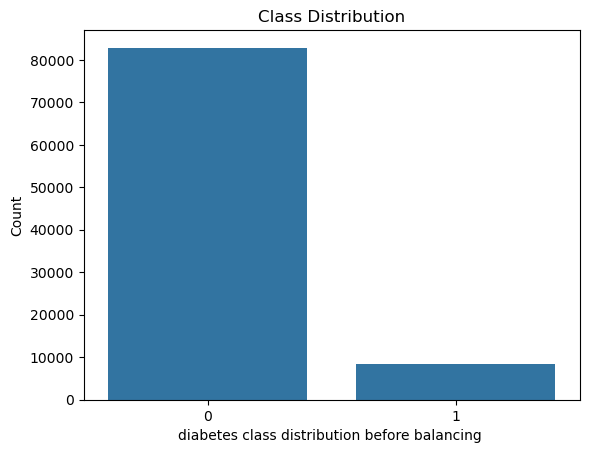

In [44]:
sns.countplot(data=df, x='diabetes')
plt.title('Class Distribution')
plt.xlabel('diabetes class distribution before balancing ')
plt.ylabel('Count')
plt.show()

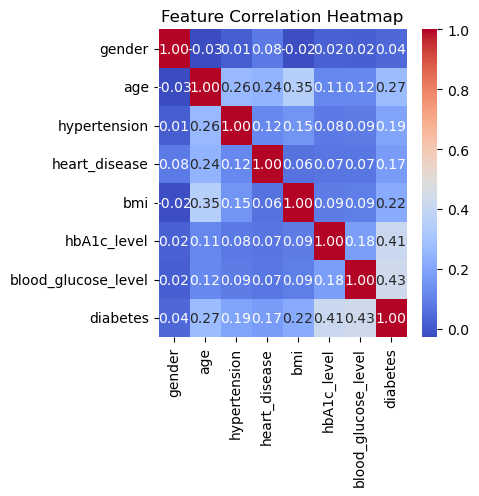

In [46]:
plt.figure(figsize=(4, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

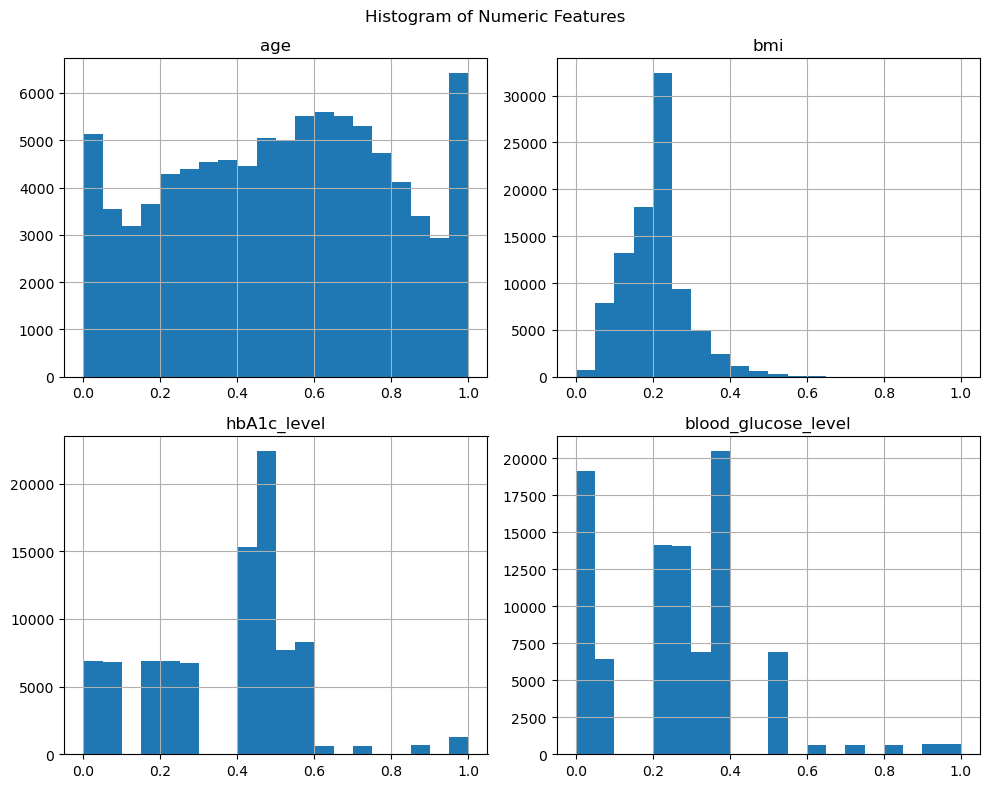

In [48]:
numeric_features = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

df[numeric_features].hist(figsize=(10, 8), bins=20)
plt.suptitle('Histogram of Numeric Features')
plt.tight_layout()
plt.show()

In [50]:
## splitting the dataset 
from imblearn.over_sampling import SMOTE
x=df.drop(columns=['diabetes'])
y=df['diabetes']
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(X_train['gender'])

0         1
1         0
2         0
3         1
4         1
         ..
132673    0
132674    0
132675    0
132676    0
132677    1
Name: gender, Length: 132678, dtype: int32


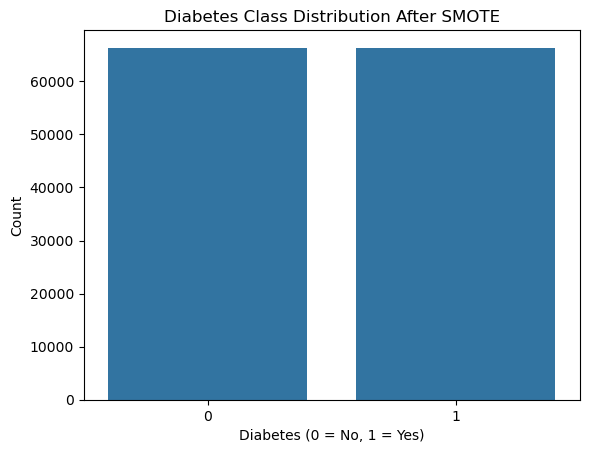

In [52]:
sns.countplot(x=y_train)
plt.title('Diabetes Class Distribution After SMOTE')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [54]:
from collections import Counter
def entropy(labels):
    """Calculate the entropy H(S)"""
    total_count = len(labels)
    counter = Counter(labels)
    ent = 0.0
    for count in counter.values():
        p = count / total_count
        ent -= p * np.log2(p)
    return ent

def conditional_entropy(X_feature, y_target):
    """Calculate the conditional entropy H(S|a)"""
    total_count = len(X_feature)
    feature_values = np.unique(X_feature)
    cond_ent = 0.0
    for value in feature_values:
        subset_y = y_target[X_feature == value]
        p = len(subset_y) / total_count
        cond_ent += p * entropy(subset_y)
    return cond_ent

def information_gain(X_feature, y_target):
    """Calculate Information Gain"""
    return entropy(y_target) - conditional_entropy(X_feature, y_target)

def split_information(X_feature):
    """Calculate the Split Information"""
    total_count = len(X_feature)
    feature_values = np.unique(X_feature)
    split_info = 0.0
    for value in feature_values:
        p = np.sum(X_feature == value) / total_count
        split_info -= p * np.log2(p)
    return split_info

def gain_ratio(X_feature, y_target):
    """Calculate the Gain Ratio"""
    ig = information_gain(X_feature, y_target)
    si = split_information(X_feature)
    if si == 0:  # to avoid division by zero
        return 0
    return ig / si


## to calculate the gain ratio for each attribute in the dataset to get the best feature we can choose 
## apply it for the training dataset


print("the gain ratio for gender",gain_ratio(X_train['gender'],y_train))
print("the gain ratio for age",gain_ratio(X_train['age'],y_train))
print("the gain ratio for hypertension",gain_ratio(X_train['hypertension'],y_train))
print("the gain ratio for bmi",gain_ratio(X_train['bmi'],y_train))
print("the gain ratio for hbA1c_level",gain_ratio(X_train['hbA1c_level'],y_train))
print("the gain ratio for blood_glucose_level",gain_ratio(X_train['blood_glucose_level'],y_train))
print("the gain ratio for heart_disease",gain_ratio(X_train['heart_disease'],y_train))
gain_ratios = {
    'gender': gain_ratio(X_train['gender'], y_train),
    'age': gain_ratio(X_train['age'], y_train),
    'hypertension': gain_ratio(X_train['hypertension'], y_train),
    'bmi': gain_ratio(X_train['bmi'], y_train),
    'hbA1c_level': gain_ratio(X_train['hbA1c_level'], y_train),
    'blood_glucose_level': gain_ratio(X_train['blood_glucose_level'], y_train),
     'heart_disease': gain_ratio(X_train['heart_disease'], y_train)
    
}

the gain ratio for gender 0.003445655119218259
the gain ratio for age 0.06159765613581888
the gain ratio for hypertension 0.07816932232153015
the gain ratio for bmi 0.05548533415358678
the gain ratio for hbA1c_level 0.08715961122118364
the gain ratio for blood_glucose_level 0.08588108689814744
the gain ratio for heart_disease 0.07538555142258652


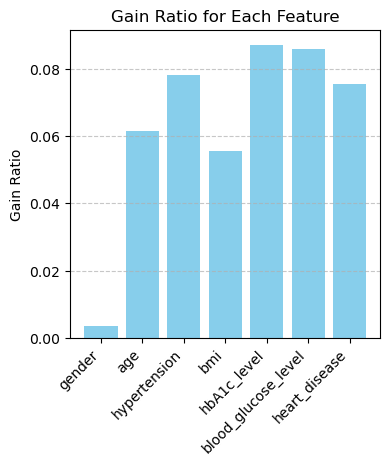

In [55]:
# Plotting the histogram
plt.figure(figsize=(4, 4))
plt.bar(gain_ratios.keys(), gain_ratios.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Gain Ratio')
plt.title('Gain Ratio for Each Feature')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [64]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid from the paper
param_grid = {
    'n_estimators': list(range(10, 101, 10)),  # numIterations
    'max_depth': [3, 5, 10, 20, 30, None]       # maxDepth (including 30 for reference)
}

# Initialize the classifier
rf = RandomForestClassifier(random_state=42)

# Define 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=cv,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)

# Fit to the training data
grid_search.fit(X_train, y_train)

# Best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

# Evaluate on test set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Set Accuracy: {:.2f}%".format(test_accuracy * 100))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best Cross-Validation Accuracy: 97.41%
Test Set Accuracy: 95.05%


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.inspection import permutation_importance
# Get the best parameters from the grid search
best_params = grid_search.best_params_

# Create the RandomForestClassifier using the best parameters
best_rf = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    random_state=42
)

# Train the model on the full training set
best_rf.fit(X_train, y_train)

# Predict on the test set
y_pred = best_rf.predict(X_test)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Set Accuracy: {:.2f}%".format(test_accuracy * 100))

Test Set Accuracy: 95.05%



Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     16512
           1       0.74      0.74      0.74      1747

    accuracy                           0.95     18259
   macro avg       0.86      0.86      0.86     18259
weighted avg       0.95      0.95      0.95     18259


Confusion Matrix:
 [[16068   444]
 [  459  1288]]


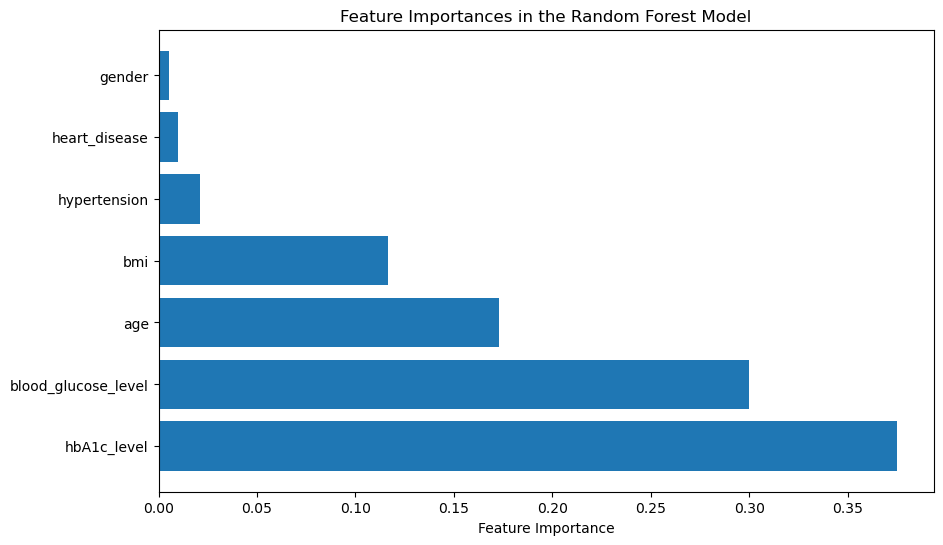

In [74]:
# Additional metrics for deeper evaluation
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# --- Visualizations ---

# 1. Feature Importance
plt.figure(figsize=(10, 6))
feature_importances = best_rf.feature_importances_
indices = feature_importances.argsort()[::-1]
plt.barh(range(len(indices)), feature_importances[indices], align='center')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Feature Importances in the Random Forest Model')
plt.show()

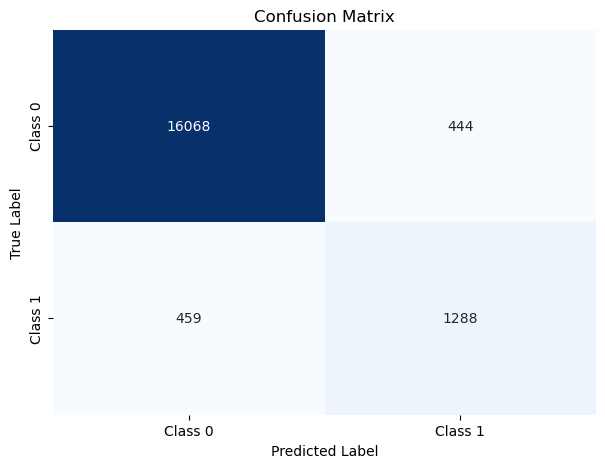

In [76]:
# 2. Confusion Matrix (Heatmap)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

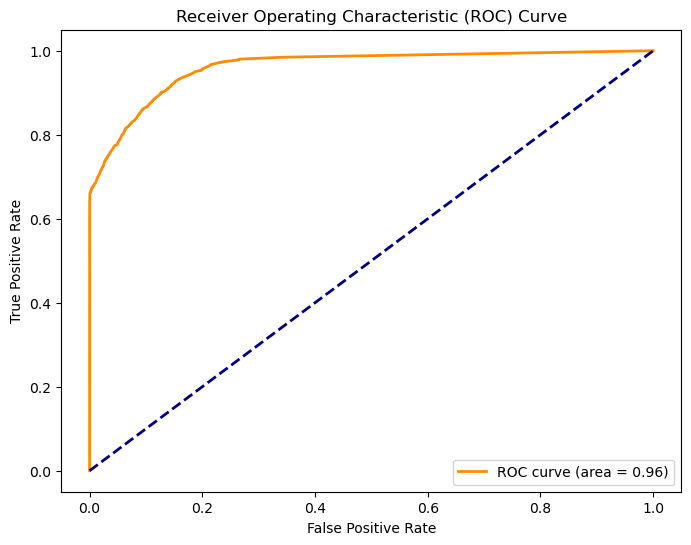

In [78]:
# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

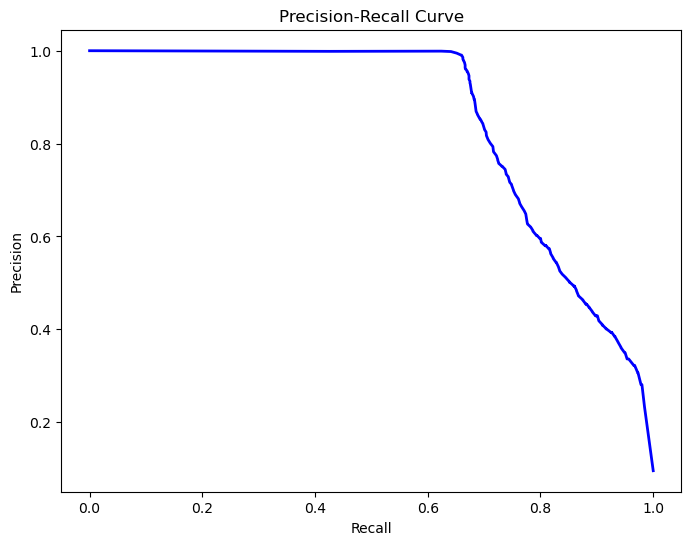

In [80]:
# 4. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

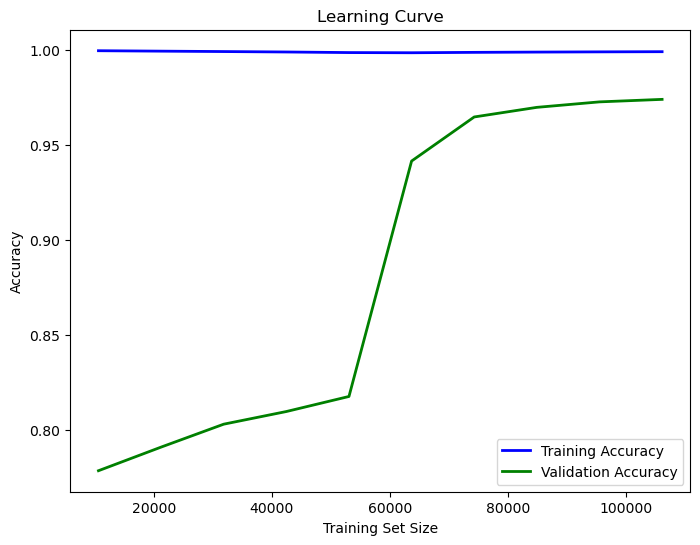

In [86]:
import numpy as np  
from sklearn.model_selection import learning_curve

# Generate learning curve data
train_sizes, train_scores, valid_scores = learning_curve(
    best_rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Plotting the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Accuracy', color='b', lw=2)
plt.plot(train_sizes, valid_scores.mean(axis=1), label='Validation Accuracy', color='g', lw=2)
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.show()